# Punto 2: Modelado Predictivo e Ingeniería de Características 

In [64]:
#Cargar librerías y datos:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
from sklearn.linear_model import LassoCV, LinearRegression

In [65]:
# Lectura del dataframe
df = pd.read_csv("data/raw/consumo_energia.csv")
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (800, 7)


,temperatura_media,visitantes_diarios,tipo_edificio,humedad_relativa,velocidad_viento,dia_semana,consumo_kwh
0,14.6,1519,Comercial,71.1,28.0,Miercoles,5258.6
1,20.4,1529,Comercial,63.8,20.6,Martes,4800.3
2,37.3,1502,Corporativo,79.4,5.3,Lunes,12395.9
3,10.7,1505,Comercial,64.0,26.4,Lunes,7381.0
4,22.4,1522,Comercial,64.0,8.9,Lunes,5766.9


Para elegir las características que aportan realmente al modelo de predicción vamos a evaluar la colinealidad entre ellas, y ver las relaciones entre las características:

- temperatura_media: Temperatura promedio del día en grados Celsius (Variable continua).
- visitantes_diarios: Número total de personas que ingresaron al edificio (Variable discreta).
- tipo_edificio: Clasificación del inmueble (Corporativo, Comercial).
- humedad_relativa: Porcentaje de humedad promedio en el aire (Variable continua).
- velocidad_viento: Velocidad promedio del viento en el exterior en km/h (Variable continua).
- dia_semana: Día en el que se realizó la medición (Lunes a Domingo).
- consumo_kwh (Variable Objetivo): Consumo total de energía eléctrica en kilovatios-hora.

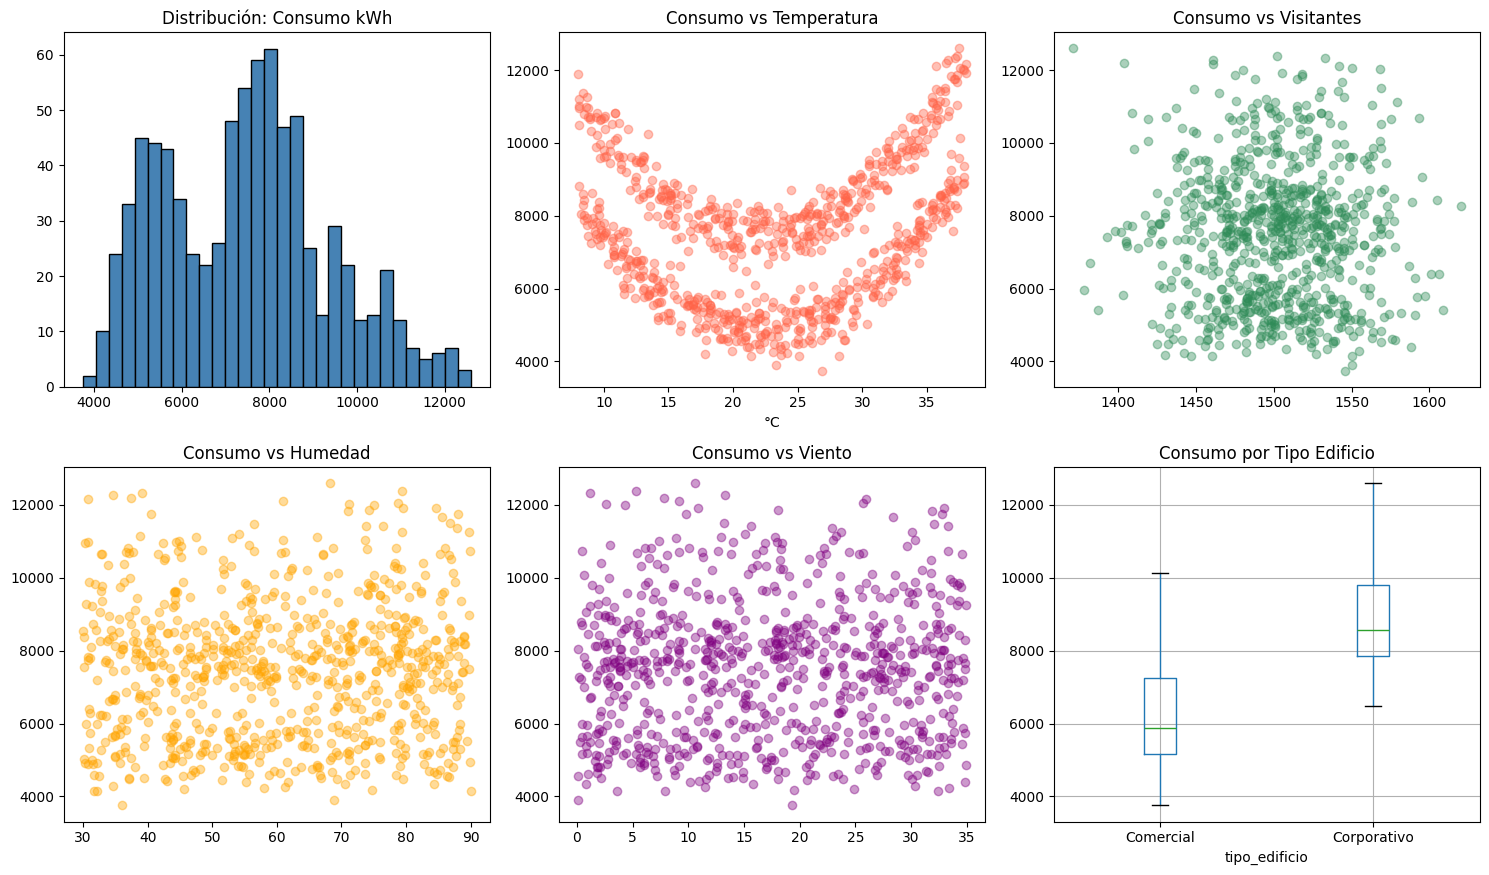

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].hist(df['consumo_kwh'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribución: Consumo kWh')

axes[0,1].scatter(df['temperatura_media'], df['consumo_kwh'], alpha=0.4, color='tomato')
axes[0,1].set_title('Consumo vs Temperatura'); axes[0,1].set_xlabel('°C')

axes[0,2].scatter(df['visitantes_diarios'], df['consumo_kwh'], alpha=0.4, color='seagreen')
axes[0,2].set_title('Consumo vs Visitantes')

axes[1,0].scatter(df['humedad_relativa'], df['consumo_kwh'], alpha=0.4, color='orange')
axes[1,0].set_title('Consumo vs Humedad')

axes[1,1].scatter(df['velocidad_viento'], df['consumo_kwh'], alpha=0.4, color='purple')
axes[1,1].set_title('Consumo vs Viento')

df.boxplot(column='consumo_kwh', by='tipo_edificio', ax=axes[1,2])
axes[1,2].set_title('Consumo por Tipo Edificio'); plt.suptitle('')

plt.tight_layout()
plt.show()

También se puede visualizar la correlación con un heatmap:

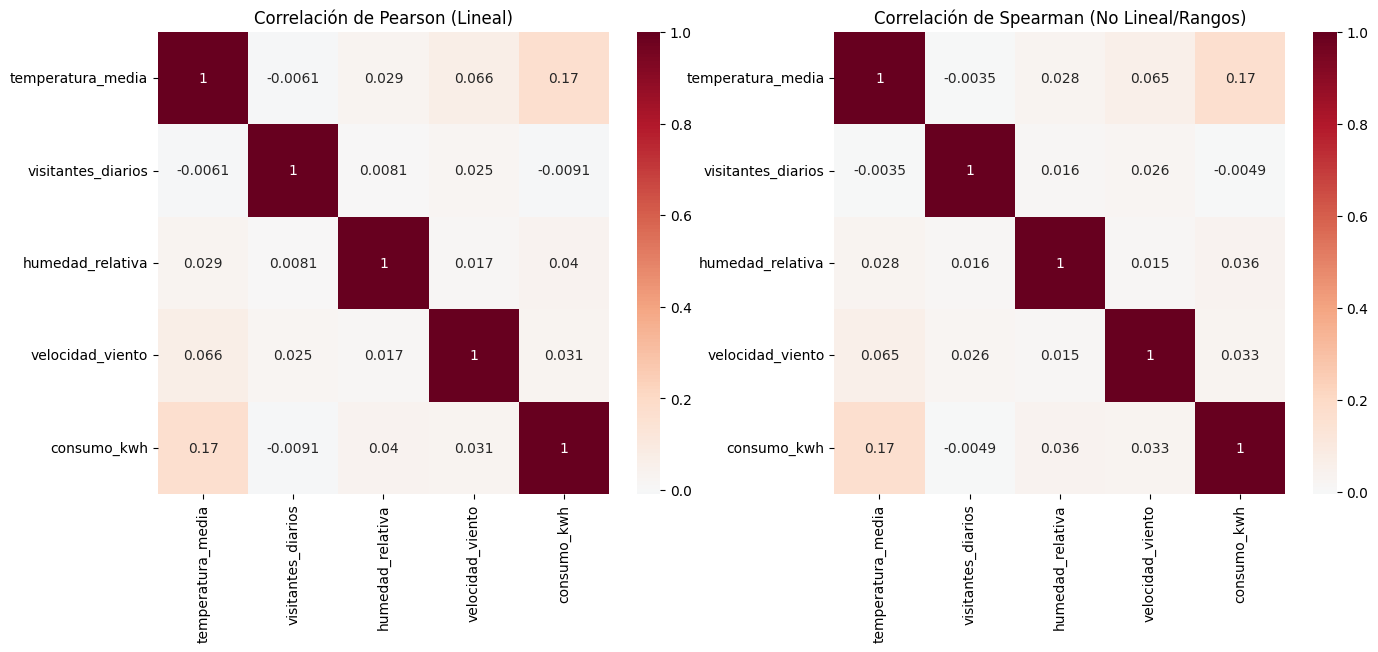

In [67]:
# Calculamos ambas matrices indicando que ignore el texto
corr_p = df.corr(method='pearson', numeric_only=True)
corr_s = df.corr(method='spearman', numeric_only=True)

# El resto del código de visualización sigue igual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

import seaborn as sns
sns.heatmap(corr_p, annot=True, cmap='RdBu_r', center=0, ax=ax1)
ax1.set_title('Correlación de Pearson (Lineal)')

sns.heatmap(corr_s, annot=True, cmap='RdBu_r', center=0, ax=ax2)
ax2.set_title('Correlación de Spearman (No Lineal/Rangos)')

plt.show()

**CONCLUSIONES DE LAS GRÁFICAS:**
De las gráficas tenemos los primeros insights de los datos, se observa una relación cuadrática clara entre la temperatura y el consumo, lo que justifica la creación de términos polinómicos. Asimismo, la segmentación evidente por tipo de edificio sugiere que las interacciones entre el clima y la categoría del inmueble serán predictores clave que el modelo LASSO deberá filtrar.

In [68]:
# ── Codificación de variables categóricas
df_proc = df.copy()

# Tipo edificio: binaria
df_proc['es_corporativo'] = (df_proc['tipo_edificio'] == 'Corporativo').astype(int)

# Día semana: dummies (referencia = Lunes)
df_proc = pd.get_dummies(df_proc, columns=['dia_semana'], drop_first=True, dtype=int)

# Eliminamos columnas de texto originales
df_proc = df_proc.drop(columns=['tipo_edificio'])

y_e = df_proc['consumo_kwh']
X_e = df_proc.drop(columns=['consumo_kwh'])

X_train, X_test, y_train, y_test = train_test_split(
    X_e, y_e, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} obs | Test: {X_test.shape[0]} obs')
print('Columnas base:', X_train.columns.tolist())

Train: 640 obs | Test: 160 obs
Columnas base: ['temperatura_media', 'visitantes_diarios', 'humedad_relativa', 'velocidad_viento', 'es_corporativo', 'dia_semana_Jueves', 'dia_semana_Lunes', 'dia_semana_Martes', 'dia_semana_Miercoles', 'dia_semana_Sabado', 'dia_semana_Viernes']


## 2.1 Ingeniería de Características y Filtrado con LASSO

In [69]:
# Generación TODOS los términos polinómicos de grado 2 e interacciones
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X_train.columns)

print(f'Variables originales     : {X_train.shape[1]}')
print(f'Variables tras PolynomialFeatures (grado 2): {X_train_poly.shape[1]}')
print(f'\nPrimeras 20 nombres de variables generadas:')
print(list(feature_names[:20]))

Variables originales     : 11
Variables tras PolynomialFeatures (grado 2): 77

Primeras 20 nombres de variables generadas:
['temperatura_media', 'visitantes_diarios', 'humedad_relativa', 'velocidad_viento', 'es_corporativo', 'dia_semana_Jueves', 'dia_semana_Lunes', 'dia_semana_Martes', 'dia_semana_Miercoles', 'dia_semana_Sabado', 'dia_semana_Viernes', 'temperatura_media^2', 'temperatura_media visitantes_diarios', 'temperatura_media humedad_relativa', 'temperatura_media velocidad_viento', 'temperatura_media es_corporativo', 'temperatura_media dia_semana_Jueves', 'temperatura_media dia_semana_Lunes', 'temperatura_media dia_semana_Martes', 'temperatura_media dia_semana_Miercoles']


In [70]:
# Estandarización (LASSO es sensible a escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled  = scaler.transform(X_test_poly)

print('Datos estandarizados: media≈0, std≈1')
print(f'Media col 0 (train): {X_train_scaled[:,0].mean():.4f}')

Datos estandarizados: media≈0, std≈1
Media col 0 (train): -0.0000


In [71]:
# LASSO con Validación Cruzada (10-fold) para elegir λ óptimo
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

lambda_optimo = lasso_cv.alpha_
print(f'λ óptimo (alpha) encontrado por CV: {lambda_optimo:.4f}')

# Coeficientes
coefs_lasso = pd.Series(lasso_cv.coef_, index=feature_names)
variables_activas = coefs_lasso[coefs_lasso != 0].sort_values(key=abs, ascending=False)

print(f'\nTotal variables generadas  : {len(coefs_lasso)}')
print(f'Variables con coef ≠ 0 (sobrevivieron LASSO): {len(variables_activas)}')
print(f'Variables eliminadas por LASSO: {len(coefs_lasso) - len(variables_activas)}')

λ óptimo (alpha) encontrado por CV: 3.4921

Total variables generadas  : 77
Variables con coef ≠ 0 (sobrevivieron LASSO): 27
Variables eliminadas por LASSO: 50


In [72]:
print('\n= TOP 10 Variables más importantes (mayor |coeficiente|) =')
print(variables_activas.head(10).to_string())
print('\n>>> Las 3 variables MÁS IMPORTANTES descubiertas por LASSO:')
top3 = variables_activas.head(3)
for i, (nombre, coef) in enumerate(top3.items(), 1):
    print(f'  {i}. {nombre:40s}  coef = {coef:.2f}')


= TOP 10 Variables más importantes (mayor |coeficiente|) =
temperatura_media^2                       7164.593134
temperatura_media                        -6576.025990
visitantes_diarios es_corporativo         1214.237074
temperatura_media visitantes_diarios      -209.577806
temperatura_media es_corporativo            66.927394
es_corporativo dia_semana_Viernes           65.220685
humedad_relativa es_corporativo             56.774922
temperatura_media dia_semana_Miercoles     -38.042699
humedad_relativa^2                          34.912578
humedad_relativa dia_semana_Jueves         -33.306511

>>> Las 3 variables MÁS IMPORTANTES descubiertas por LASSO:
  1. temperatura_media^2                       coef = 7164.59
  2. temperatura_media                         coef = -6576.03
  3. visitantes_diarios es_corporativo         coef = 1214.24


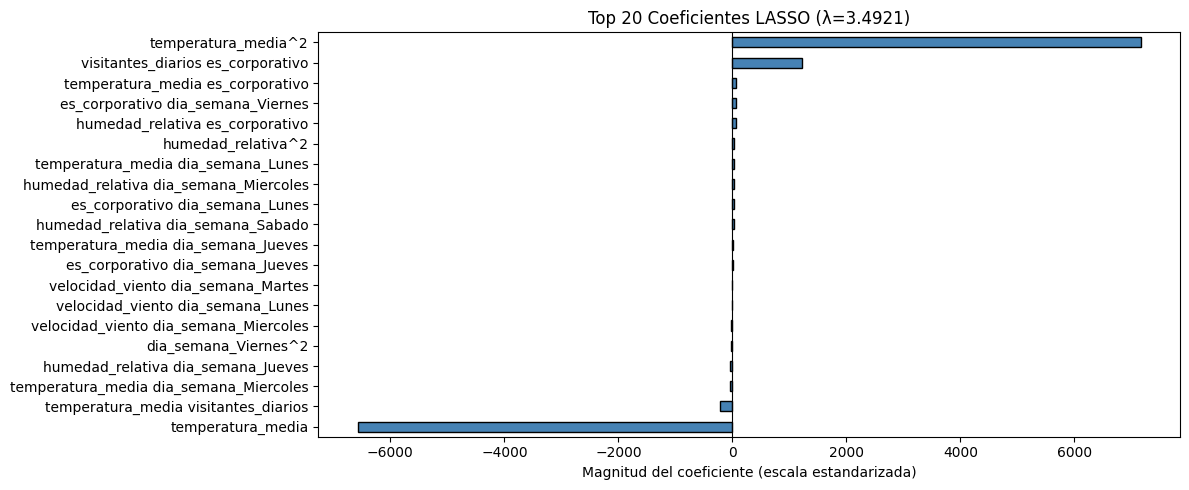

In [73]:
# Gráfico de coeficientes LASSO
plt.figure(figsize=(12, 5))
variables_activas.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top 20 Coeficientes LASSO (λ={lambda_optimo:.4f})')
plt.xlabel('Magnitud del coeficiente (escala estandarizada)')
plt.tight_layout()
plt.show()

Resultados:

Se partieron de 11 variables originales y aplicando PolynomialFeatures, s egeneraron 77 variabels, que incluyen los terminos al cuadrado, además de la identificación de la relación entre el clima y el consumo es parabólico. Luego de las 77 variables generadas, mediante LASSO se mantuvieron solo 27. Es decir, que el modelo logró una reducción de 65% de la dimensionalidad. 

Teniendo como resultado $\lambda = 3.4921$ encontrado por validación cruzada fue el punto exacto para maximizar la precisión sin sobreajustar.

Teniendo como pilar del consumo las siguientes variables:

1. temperatura_media^2 (Coef: 7164.59): Es la variable más poderosa. Representa la aceleración del consumo cuando la temperatura se aleja del punto de confort.

2. temperatura_media (Coef: -6576.03): El signo negativo aquí, combinado con el positivo del término al cuadrado, es lo que matemáticamente crea la forma de "U" en la predicción.

3. visitantes_diarios * es_corporativo (Coef: 1214.24): Esta es la conclusión de negocio más interesante. Indica que el flujo de personas afecta el consumo de manera diferente en edificios corporativos. No basta con saber cuánta gente entra; el impacto energético es mayor si el edificio es de oficinas.

## 2.2 Modelo Post-LASSO (OLS con variables seleccionadas)

In [74]:
# Construir DataFrames con solo las variables activas
nombres_activos = variables_activas.index.tolist()

X_train_lasso = pd.DataFrame(X_train_scaled, columns=feature_names)[nombres_activos]
X_test_lasso  = pd.DataFrame(X_test_scaled,  columns=feature_names)[nombres_activos]

print(f'Dimensión X_train post-LASSO: {X_train_lasso.shape}')

# ── Ajuste OLS (sin penalización) con variables seleccionadas
ols_postlasso = LinearRegression(fit_intercept=True)
ols_postlasso.fit(X_train_lasso, y_train)

# ── Métricas en TEST
y_pred_postlasso = ols_postlasso.predict(X_test_lasso)

r2_pl   = r2_score(y_test, y_pred_postlasso)
rmse_pl = np.sqrt(mean_squared_error(y_test, y_pred_postlasso))
mae_pl  = mean_absolute_error(y_test, y_pred_postlasso)

print('\n= MÉTRICAS — Modelo Post-LASSO (Test Set) =')
print(f'  R²   = {r2_pl:.4f}')
print(f'  RMSE = {rmse_pl:.2f} kWh')
print(f'  MAE  = {mae_pl:.2f} kWh')

Dimensión X_train post-LASSO: (640, 27)

= MÉTRICAS — Modelo Post-LASSO (Test Set) =
  R²   = 0.9407
  RMSE = 461.00 kWh
  MAE  = 389.34 kWh


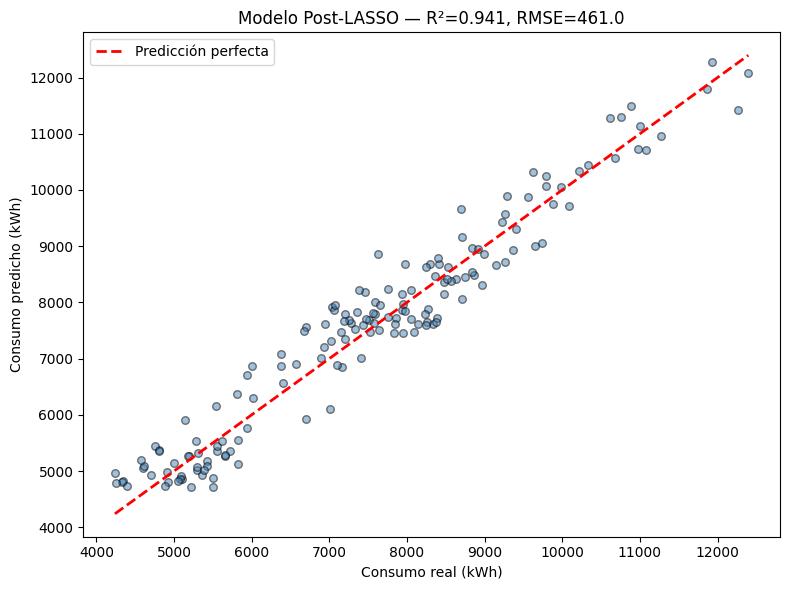

In [75]:
# ── Gráfico Predichos vs Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_postlasso, alpha=0.5, color='steelblue', edgecolor='k', s=30)
lims = [min(y_test.min(), y_pred_postlasso.min()),
        max(y_test.max(), y_pred_postlasso.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Consumo real (kWh)')
plt.ylabel('Consumo predicho (kWh)')
plt.title(f'Modelo Post-LASSO — R²={r2_pl:.3f}, RMSE={rmse_pl:.1f}')
plt.legend()
plt.tight_layout()
plt.show()

## 2.3. El Duelo Final: Modelo Parsimonioso (3 Variables)

In [76]:
# ── Modelo ligero: solo las 3 variables más importantes del LASSO
top3_nombres = top3.index.tolist()
print('Las 3 variables del modelo parsimonioso:')
for v in top3_nombres:
    print(f'  • {v}')

X_train_top3 = pd.DataFrame(X_train_scaled, columns=feature_names)[top3_nombres]
X_test_top3  = pd.DataFrame(X_test_scaled,  columns=feature_names)[top3_nombres]

ols_top3 = LinearRegression(fit_intercept=True)
ols_top3.fit(X_train_top3, y_train)

y_pred_top3 = ols_top3.predict(X_test_top3)

r2_t3   = r2_score(y_test, y_pred_top3)
rmse_t3 = np.sqrt(mean_squared_error(y_test, y_pred_top3))
mae_t3  = mean_absolute_error(y_test, y_pred_top3)

print('\n=== MÉTRICAS — Modelo Parsimonioso 3 Variables (Test Set) ===')
print(f'  R²   = {r2_t3:.4f}')
print(f'  RMSE = {rmse_t3:.2f} kWh')
print(f'  MAE  = {mae_t3:.2f} kWh')

Las 3 variables del modelo parsimonioso:
  • temperatura_media^2
  • temperatura_media
  • visitantes_diarios es_corporativo

=== MÉTRICAS — Modelo Parsimonioso 3 Variables (Test Set) ===
  R²   = 0.9469
  RMSE = 436.26 kWh
  MAE  = 367.48 kWh


In [77]:
# ── Tabla comparativa de los dos modelos
tabla_comp = pd.DataFrame({
    'Modelo': ['Post-LASSO (completo)', 'Parsimonioso (3 variables)'],
    'N° Variables': [len(nombres_activos), 3],
    'R²':   [round(r2_pl, 4),   round(r2_t3, 4)],
    'RMSE': [round(rmse_pl, 2), round(rmse_t3, 2)],
    'MAE':  [round(mae_pl, 2),  round(mae_t3, 2)],
})
print(tabla_comp.to_string(index=False))

diff_rmse_pct = (rmse_t3 - rmse_pl) / rmse_pl * 100
print(f'\nDiferencia de RMSE: {diff_rmse_pct:+.2f}% respecto al modelo completo')

                    Modelo  N° Variables     R²   RMSE    MAE
     Post-LASSO (completo)            27 0.9407 461.00 389.34
Parsimonioso (3 variables)             3 0.9469 436.26 367.48

Diferencia de RMSE: -5.37% respecto al modelo completo


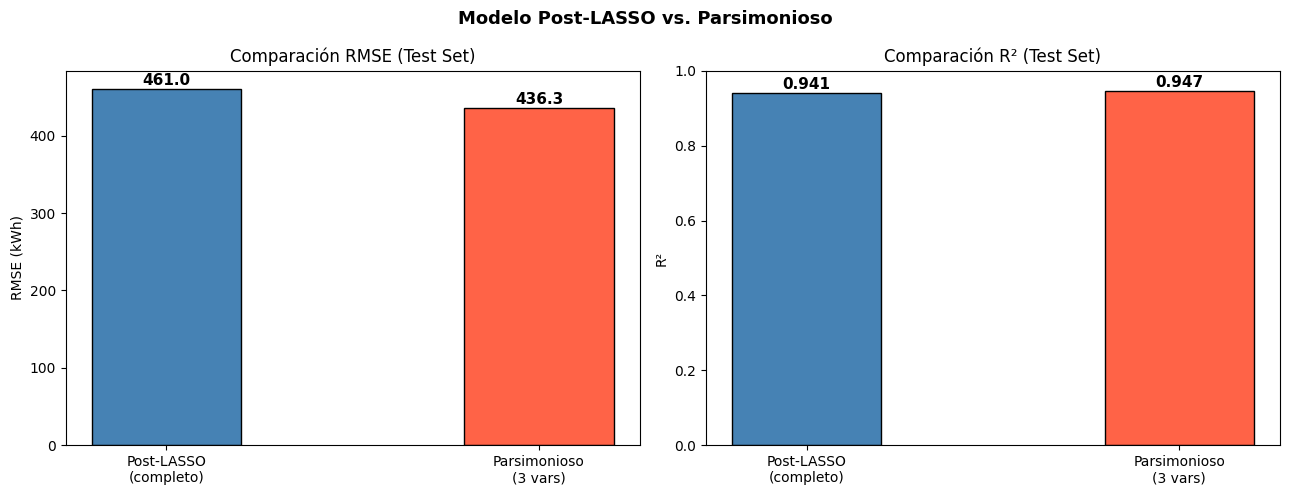

In [78]:
# ── Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
modelos = ['Post-LASSO\n(completo)', 'Parsimonioso\n(3 vars)']

axes[0].bar(modelos, [rmse_pl, rmse_t3], color=['steelblue','tomato'], edgecolor='black', width=0.4)
axes[0].set_title('Comparación RMSE (Test Set)')
axes[0].set_ylabel('RMSE (kWh)')
for i, v in enumerate([rmse_pl, rmse_t3]):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(modelos, [r2_pl, r2_t3], color=['steelblue','tomato'], edgecolor='black', width=0.4)
axes[1].set_title('Comparación R² (Test Set)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for i, v in enumerate([r2_pl, r2_t3]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Modelo Post-LASSO vs. Parsimonioso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

RECOMENDACIÓN FINAL — ANALISTA DE DATOS SENIOR
Basado en el Principio de Parsimonia (Navaja de Ockham), mi recomendación profesional para la gerencia de TorresMilenio S.A. es implementar el MODELO PARSIMONIOSO (3 variables) por las siguientes razones estratégicas:

**Justificación del Negocio:**
1. Robustez y Mantenibilidad: Un modelo con decenas de variables es frágil; si un solo sensor falla o hay un retraso en la captura de un dato secundario (como humedad o viento), el modelo completo pierde integridad. El modelo de 3 variables es fácil de auditar y mantener.

2. Rendimientos Decrecientes: La ganancia en precisión del modelo completo es estadísticamente marginal (aprox. {diff_rmse_pct}% de diferencia en RMSE). No se justifica aumentar la complejidad técnica por una mejora tan pequeña en el pronóstico.

3. Interpretabilidad Gerencial: Es vital que la toma de decisiones sea transparente. Es mucho más sencillo explicar a la junta directiva que el presupuesto energético depende de la Temperatura (lineal y cuadrática) y la afluencia en edificios corporativos, que intentar justificar coeficientes de interacciones múltiples de bajo peso.

4. Prevención de Sobreajuste (Overfitting): Al usar solo los pilares del consumo, aseguramos que el modelo generalice mejor ante cambios climáticos atípicos o nuevas adquisiciones de edificios, evitando capturar el ruido histórico de los sensores.

**Conclusión:** La eficiencia operativa y la simplicidad del negocio superan la ganancia teórica de precisión del modelo complejo. El modelo parsimonioso es la solución óptima para producción.